In [1]:
import utils
print(f"utils : {utils.__version__}")
from utils.structure import build_electrode, build_nanoribbon, build_reduced_device, find_nearest_atoms, infer_centersize
from utils.plots import plot_with_center, mark_electrode # plotting
from utils.energies import hamiltonian, multi_LDOS_parallel, multi_LDOS
from utils import pretty_print_columns
from utils._wrappers import timeit


import sisl
import numpy as np
import matplotlib.pyplot as plt
from ase.visualize import view
from tqdm.notebook import tqdm

import ipywidgets
from ipywidgets import interact
from fractions import Fraction


%reload_ext line_profiler


utils : 0.2.2


# Global parameters

In [2]:
ENERGIES = np.linspace(-2, 2, num=50)

# Benchmark full device: flake convergence
This is how I expect the final structure to converge when computing the LDOS from self-energies

In [12]:
# sizes = [10, 15, 20, 25]
# fig, axes = plt.subplots()
# COLORS = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
# LINESTYLE = [":", "-.", "--", "-"]
# ALPHA = [0.9, 0.8, 0.7, 0.6]
# LINEWIDTH = [2.5, 2.0, 1.8, 1.6][::-1]
# for i, s in enumerate(tqdm(sizes, desc="loop")):
#     pdos = make_benchmark(s, ENERGIES)
#     axes.plot(pdos, ENERGIES, label=f"{s = }",
#               alpha=ALPHA[i], color=COLORS[i],
#               linestyle=LINESTYLE[i], lw=LINEWIDTH[i])

# axes.set_xlabel("PDOS (center atom)")
# axes.set_ylabel("Energies")
# axes.legend()
# fig.suptitle(f"Flake Size PDOS Conv.")
# fig.savefig("figures/graphene_flake_PDOS_convergence.png")


<img src="figures/graphene_flake_PDOS_convergence.png">

In [13]:
# def mark_electrode(lr_indices):
#     """Helper function for plotting electrodes.
#     Colors 'left' and 'right' electrodes using blue and red respectively.
#     Scales the atom sizes to match opposing electrodes."""
#     atoms_style = []
#     for i, (l, r) in enumerate(zip(*lr_indices)):
#         atoms_style += [{"atoms": l, "size": i*0.3 + 0.5, "color": "blue"}]
#         atoms_style += [{"atoms": r, "size": i*0.3 + 0.5, "color": "red"}]
#     return atoms_style

In [14]:
@timeit
def electrode_dos(ham, nk, energies):
    """compute DOS from built-ins
    
    Parameters
    ----------
    ham : Hamiltonian of shape (K, K)
        Hamiltonian in question 
    nk : int
        number of k points
    energies : ndarray of shape (N,)
        list of energies to compute the dos

    Returns
    -------
    dos : ndarray of shape (N,)
        density of state
    bs : ndarray of shape (M, N)
        bandstructure eigenvalues 
    lk : ndarray of shape (M,)
        scaled kpoints to linear values for use in plotting
    """
    dist = sisl.get_distribution(method="lorentzian", smearing=0.05)
    
    bz = sisl.MonkhorstPack(ham, [nk, 1, 1])
    kvecs = [[0,0,0], [0.5, 0, 0]]
    bands = sisl.BandStructure(ham, kvecs, 15, [r"$\Gamma$", "$K$"])
    lk, kticks, knames = bands.lineark(ticks=True)
    bs = bands.apply.array.eigh()
    dos = (bz.apply.average).eigenstate(wrap = lambda x: x.DOS(energies, distribution=dist)) 
    return dos, bs, (lk, kticks, knames)

# Benchmark Electrode: self-energy method against built-in

In [3]:
i = 1
length = 2
lenght, width, center_size = infer_centersize(length, i)

__params__ribbon = f"{length}L_{width}W_{center_size}C"
print(f"{__params__ribbon = }")
electrode = build_electrode(width=width, length=length)
ribbon = build_nanoribbon(electrode=electrode, center_size=center_size)
device_ribbon, lr_idx_ribbon = build_reduced_device(ribbon, electrode, repeat=1)
# device_ribbon.write(f"structures/ribbon_{__params__ribbon}.xyz")
atoms_style = mark_electrode(lr_idx_ribbon)
device_ribbon.plot(axes="xy", atoms_style=atoms_style)

plot_with_center(device_ribbon, atoms_style=atoms_style)

(l, i) = (2, 1) are incompatbile. Increasing i.
__params__ribbon = '2L_9W_2C'
       Initial number of atoms: 144
 Atoms after removing overlaps: 144


In [19]:
def plot_dos_band(device, nk, energies):
    """Plot the device band structure and DOS"""
    H = hamiltonian(device)
    dos, bands, k = electrode_dos(H, nk, energies)
    fig, axes = plt.subplots(1,2, sharey=True)
    fig.suptitle(f"Built-in calc L={length}, W={width}, C={center_size}")
    axes[0].set_title("Band structure")    
    axes[0].plot(k[0], bands)    
    axes[0].set_xlabel("$k$", size=15)
    axes[0].set_xticks(k[1])
    axes[0].set_xticklabels(k[2])
    
    axes[1].set_title("DOS")
    axes[1].plot(dos, energies, label="built-in DOS")
    axes[1].set_xlabel("DOS", size=15)
    
    axes[0].set_ylabel("E", size=15)
    fig.tight_layout()
    for ax in axes:
        ax.grid()
    
    return fig, axes

## Built-in calculations for bands and DOS

In [20]:
test, res = divmod(10, 3)
print(f"{test:02}: {res:02.3f}")

03: 1.000


func 'electrode_dos' with args : -not implemented-  ran in 0.0:0.0:0.032


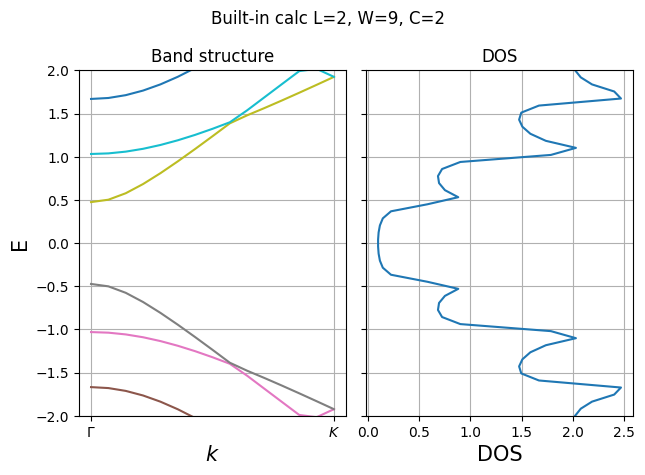

In [21]:
# _electrode = electrode.copy()
fig, axes = plot_dos_band(electrode, 100, ENERGIES)
minmax = 2
axes[0].set(ylim=(-minmax, minmax))
fig.savefig(f"figures/electrode_bands_DOS_{__params__ribbon}.png")

## Self-energy LDOS VS. built-in DOS 

In [22]:
# Nk = 1
# all_ldos = multi_LDOS(device=device_ribbon, 
#                      electrode=electrode, 
#                      lr_indices=lr_idx_ribbon, 
#                      energies=ENERGIES, Nk=Nk, eta=1e-5, form="csc") # self-energy calc. LDOS NSC = [1,1,1]

# dos, bs, lk = electrode_dos(hamiltonian(device_ribbon), 100, ENERGIES) # assumes PBC - NSC=[3,1,1]

# np.savez(f"calculations/ribbon_ldos_{__params__ribbon}", energies=ENERGIES, 
#          ldos=all_ldos, dos=dos, bs=bs, lineark=lk[0], kxpos=lk[1], klab=lk[2])
# print(f"{__params__ribbon =}")


## Plotting LDOS VS. dos

Does not require to run previous cells

In [23]:
# w = 40
# l = 2
# c = 3
# Nk = 1
# PARAMS_ribbon = f"{w}W_{l}L_{c}C"
# DATA = np.load(f"calculations/ribbon_ldos_{PARAMS_ribbon}.npz")
# energies, ldos, dos, bs, ks, kpos, klabels = (DATA["energies"], DATA["ldos"], DATA["dos"], DATA["bs"], DATA["lineark"], DATA["kxpos"], DATA["klab"])
# device_ribbon = sisl.io.get_sile(f"structures/ribbon_{PARAMS_ribbon}.xyz").read_geometry()

In [24]:
# plot_with_center(device_ribbon,
#                 #  atoms_style=atoms_style
#                  )#

In [25]:
# def plot_ldos(kidx, site, fixed_scale, samefig=True):
#     print(ldos.shape)
#     """Plot LDOS from self-energy calculation with DOS from built-ins"""
    
#     X1 = ldos[kidx, :, site]
#     X2 = dos
    
#     # only used if fixed_scale=True
#     ymin, ymax = np.min([np.min(ldos), np.min(dos)]), np.max([np.max(ldos), np.max(dos)])
    
#     if samefig: # plot in the save figure
#         fig, axes = plt.subplots(1,1)
    
#         normalize = lambda arr: (arr - arr.mean()) / arr.std()
#         X1 = normalize(X1)
#         X2 = normalize(X2)
#         axes.plot(X1, energies, label="SE (LDOS)")
#         axes.plot(X2, energies, label="Built-in (DOS)")
#         axes.set_xlabel("DOS (normalized)")
#         axes.legend()
#         axes.set_ylabel("E")
#         axes.set_title("DOS for nanoribbon")
#         if fixed_scale:
#             # ymin, ymax = np.min([np.min(all_ldos), np.min(dos)]), np.max([np.max(all_ldos), np.max(dos)])
#             axes.set_xlim(-ymax*0.1, ymax*1.01)
    
#     else: # plot as subfigure
#         fig, axes = plt.subplots(1,2, sharey=True)
#         axes[0].plot(X1, energies)
#         axes[0].set_title("SE (LDOS)")
#         axes[0].set_ylabel("Energies")
        
#         axes[1].plot(X2, energies)
#         axes[1].set_title("Built-in (DOS)")
        
#         for ax in axes:
#             ax.set_xlabel("DOS")
#             if fixed_scale:
#                 ax.set_xlim(-ymax*0.1, ymax*1.01)
#     title_strlist = PARAMS_ribbon.split("_")
#     parse_number = lambda string: int("".join(ch for ch in string if ch.isdigit()))
#     for title_str in title_strlist:
#         if "W" in title_str:
#             w = parse_number(title_str)
#         elif "L" in title_str:
#             l = parse_number(title_str)
#         elif "C" in title_str:
#             c = parse_number(title_str)
#     fig.suptitle(f"L={l}, W={w}, C={c}")

# def interactive_params(device, Nk):
#     DEVICE_CENTER_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
#     # print(DEVICE_CENTER_ATOMS)

#     kpts = sisl.MonkhorstPack(hamiltonian(device), [Nk, 1, 1])
#     options = [(f"{[str(Fraction(val).limit_denominator(len(kpts)*2)) for val in kvec]})", i) for i, kvec in enumerate(kpts)]
#     ks = ipywidgets.Dropdown(options=options, description="k")
#     # static = ipywidgets.fixed(all_ldos)
#     # sites = ipywidgets.IntSlider(min=left_idx[0].max()+1, max=right_idx[0].min()-1, value=left_idx[0].min(), description="Site")
#     sites = ipywidgets.Dropdown(options=DEVICE_CENTER_ATOMS, description="Site")

#     scale = ipywidgets.Checkbox(value=False, description="Use fixed scale", indent=True)
#     same = ipywidgets.Checkbox(value=True, description="Plot in same figure", indent=True)
#     return ks, sites, scale, same


In [26]:
# ks, sites, scale, same = interactive_params(device_ribbon, Nk=Nk)
# interact(plot_ldos, kidx=ks, site=sites, fixed_scale=scale, samefig=same)


In [27]:
# atoms_style = mark_electrode(lr_idx_ribbon)
# plot_with_center(device_ribbon, 
#                 #  atoms_style=atoms_style
#                  )

# Convergence for device: Reduced structure (3 arms)

In [ ]:
# def infer_centersize(l, i):
#     """
#     Given L and a starting i, find the smallest i >= given i
#     such that C = 2*(1+i)/l is a positive integer.
#     Returns (L, W, C).
#     """
#     if l < 1:
#         raise ValueError("l must be at least 1")
#     if i < 0:
#         raise ValueError("i must be non-negative")
    
#     # we want  L | (2*(i+1))  meaning 2(1+i) is divisible by L yielding an integer.
#     # ("|" means that for an integer k: 2*(i+1) = kL)
    
#     # so 2*(1+i) = 0 mod L -> i = -1 mod (L/gcd(L, 2))
#     import math
#     g = math.gcd(l, 2)
#     spacing = l // g # modulus for i
    
#     # solve for i = -1 (mod s), but Python want positives
#     target = (-1) % spacing
    
#     # print(f"{spacing = }")
#     # print(f"{target = }")
#     # print(f"{i = }")
#     # print(f"{target - i = }")
#     # print(f"{-1 % spacing = }")
#     # print(f"{(target-i)%spacing = }")
#     if i <= target:
#         i = target
#     else:
#         print(f"{(l, i) = } are incompatbile. Increasing i.")
#         i = i + ((target - i) % spacing)
    
#     w = 5 + i*4
#     c = 2*(1+i)//l # integer
#     return l, w, c
# infer_centersize(3, 3)

(l, i) = (3, 3) are incompatbile. Increasing i.


(3, 25, 4)

In [20]:
i = 12
length = 2

length, width, center_size = infer_centersize(length, i)
# width += 2
__params__electrode = f"{length}L_{width}W"
__params__device = __params__electrode + f"_{center_size}C"
electrode = build_electrode(width=width, length=length)
ribbon = build_nanoribbon(electrode=electrode, center_size=center_size)
device, lr_idx_device = build_reduced_device(ribbon, electrode, repeat=3)
print(f"{__params__device.split("_")}")
atoms_style = mark_electrode(lr_idx_device)

plot_with_center(device, atoms_style=atoms_style)

(l, i) = (2, 12) are incompatbile. Increasing i.
       Initial number of atoms: 9540
 Atoms after removing overlaps: 5328
['2L', '53W', '13C']


In [ ]:
Nk = 1
device.write(f"structures/device_{__params__device}.xyz")
device.write(f"structures/electrode_{__params__electrode}.xyz")
all_ldos = multi_LDOS(device=device, 
                     electrode=electrode, 
                     lr_indices=lr_idx_device, 
                     energies=ENERGIES, Nk=Nk, eta=1e-5, form="csc")

# dos, bs, lk = electrode_dos(hamiltonian(device), 100, ENERGIES)

np.savez(f"calculations/device_ldos_{__params__device}", energies=ENERGIES, ldos=all_ldos, lr_idx = lr_idx_device
        #  dos=dos, bs=bs, lineark=lk[0], kxpos=lk[1], klab=lk[2]
         )
print(f"saved with parameters : {__params__device}")

In [ ]:
def load_datastructure(dims=(1,5,2)):
    l, w, c = dims
    params_string = f"{l}L_{w}W_{c}C"
    DATA = np.load(f"calculations/device_ldos_{params_string}.npz")
    device = sisl.io.get_sile(f"structures/device_{params_string}.xyz").read_geometry()
    energies, ldos, lr_idx = DATA["energies"], DATA["ldos"], DATA["lr_idx"]
    print(f"params : (L, W, C) = {dims}")
    return device, energies, ldos, lr_idx, params_string
    

In [ ]:
l = 1
i = 4
l, w, c = infer_centersize(l, i)
# l, w, c = 1, 37, 18
device, energies, ldos, lr_idx, PARAMS = load_datastructure(dims=(l,w,c))

atoms_style = mark_electrode(lr_idx)



plot_with_center(device, atoms_style=atoms_style)

(l, i) = (1, 4) are incompatbile. Increasing i.


NameError: name 'load_datastructure' is not defined

## Plotting LDOS VS. DOS*
*DOS is likely not right - calculated assuming 'pristine'

In [ ]:
def interactive_params(device, Nk):
    # Determine k-point options
    DEVICE_CENTER_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
    kpts = sisl.MonkhorstPack(hamiltonian(device), [Nk, 1, 1])
    options = [(f"{[str(Fraction(val).limit_denominator(len(kpts)*2)) for val in kvec]})", i) for i, kvec in enumerate(kpts)]
    ks = ipywidgets.Dropdown(options=options, description="k")
    
    # Determine site (only the centermost)
    sites = ipywidgets.Dropdown(options=DEVICE_CENTER_ATOMS, description="Site")
    
    # Option for using normalized data : (val - mean) / std
    norm = ipywidgets.Checkbox(value=False, description="Normalize", indent=True)
    # same = ipywidgets.Checkbox(value=True, description="Plot in same figure", indent=True)
    return ks, sites, norm


In [ ]:
from sisl.viz.processors.math import normalize
def plot_ldos(kidx, s, norm=True):
    """Plot LDOS from self-energy calculation."""
    # print(ldos.shape)
    # print(f"{sites.options = }")
    vmin = ldos[kidx, :, sites.options].mean()
    # print(f"{vmin}")
    
    X1 = ldos[kidx, :, s]
    
    fig, axes = plt.subplots(1,1)
    if norm: # plot in the save figure
        X1 = normalize(X1, vmin=vmin, vmax = 1)
        axes.set_xlabel("LDOS (normalized)")
    else:
        axes.set_xlabel(f"LDOS")
    
    axes.plot(X1, energies, label="SE (LDOS)")
    axes.set_ylabel("E")
    axes.axvline(0)
    
    
    title_strlist = PARAMS.split("_") # split string to list with "_" as seperator
    parse_number = lambda string: int("".join(ch for ch in string if ch.isdigit())) # find number in string
    for title_str in title_strlist:
        if "W" in title_str: # find width
            w = parse_number(title_str)
        elif "L" in title_str: # find length
            l = parse_number(title_str)
        elif "C" in title_str: # find center size
            c = parse_number(title_str)
    fig.suptitle(f"L={l}, W={w}, C={c}")

ks, sites, norm = interactive_params(device, Nk=Nk)
interact(plot_ldos, kidx=ks, s=sites, norm=norm)

warn:0: SislWarning:

Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.



interactive(children=(Dropdown(description='k', options=(("['0', '0', '0'])", 0),), value=0), Dropdown(descrip…

<function __main__.plot_ldos(kidx, s, norm=True)>

## Plot LDOS pr. energy (interactive)

In [ ]:
from sisl.viz.processors.math import normalize
def scale_by_ldos(ldos, Eidx, atoms_style = None):
    scaling = lambda E: 10*E + 0.02
    Nk, NE, Ns = ldos.shape
    C_ATOMS = find_nearest_atoms(device.xyz, device.center(), neighbours=6)
    vmin = ldos[..., C_ATOMS].mean()
    
    
    norm_ldos = normalize(ldos, vmin=vmin, vmax=1)
    style = {"atoms": range(Ns),
             "size": scaling(norm_ldos[0, Eidx, :])}
    if atoms_style is None:
        atoms_style = []
    
    atoms_style.append(style)
    return atoms_style
    
style = scale_by_ldos(ldos, 0, atoms_style)

In [ ]:
print(PARAMS)
_atoms_style = mark_electrode(lr_idx)

def proj_ldos(Eidx):
    _style = scale_by_ldos(ldos, Eidx, _atoms_style)
    fig = device.plot(axes="xy", atoms_style=_style, backend="matplotlib", show_cell=False)
        
        
    fig.suptitle(f"{PARAMS}, E = {ENERGIES[Eidx]:.3f}")
    fig.show()
    # return fig

# idxs = ipywidgets.Dropdown(options=range(ENERGIES.shape[0]), description="E")
idxs = ipywidgets.IntSlider(min=0, max=len(ENERGIES)-1, description="E")
interact(proj_ldos, Eidx=idxs)

2L_25W_6C


interactive(children=(IntSlider(value=0, description='E', max=49), Output()), _dom_classes=('widget-interact',…

<function __main__.proj_ldos(Eidx)>

In [ ]:
@timeit
def electrode_dos(ham, nk, energies):
    """compute DOS from built-ins
    
    Parameters
    ----------
    ham : Hamiltonian of shape (K, K)
        Hamiltonian in question 
    nk : int
        number of k points
    energies : ndarray of shape (N,)
        list of energies to compute the dos

    Returns
    -------
    dos : ndarray of shape (N,)
        density of state
    bs : ndarray of shape (M, N)
        bandstructure eigenvalues 
    lk : ndarray of shape (M,)
        scaled kpoints to linear values for use in plotting
    """
    # ham = hamiltonian(electrode)
    
    dist = sisl.get_distribution(method="lorentzian", smearing=0.05)
    
    bz = sisl.MonkhorstPack(ham, [1, nk, 1])
    kvecs = [[0,0,0], [0.5, 0, 0]]
    bands = sisl.BandStructure(ham, kvecs, 15, [r"$\Gamma$", "$K$"])
    lk, kticks, knames = bands.lineark(ticks=True)
    bs = bands.apply.array.eigh()
    dos = (bz.apply.average).eigenstate(wrap = lambda x: x.DOS(energies, distribution=dist)) 
    return dos, bs, (lk, kticks, knames)

def plot_dos_band(device,  nk, energies):
    """Plot the device band structure and DOS"""
    H = hamiltonian(device)
    H.set_nsc([1, 3, 1]) # make the y-direction repeating - x direction is used for self-energy
    
    dos, bands, k = electrode_dos(H, nk, energies)
    fig, axes = plt.subplots(1,2, sharey=True)
    fig.suptitle(f"Built-in calc L={length}, W={width}, C={center_size}")
    axes[0].set_title("Band structure")    
    axes[0].plot(k[0], bands)    
    axes[0].set_xlabel("$k$", size=15)
    axes[0].set_xticks(k[1])
    axes[0].set_xticklabels(k[2])
    
    axes[1].set_title("DOS")
    axes[1].plot(dos, energies, label="built-in DOS")
    axes[1].set_xlabel("DOS", size=15)
    
    axes[0].set_ylabel("E", size=15)
    fig.tight_layout()
    for ax in axes:
        ax.grid()
    
    return fig, axes

func 'electrode_dos' with args : -not implemented-  ran in 0.0:0.0:49.807


[(-2.0, 2.0)]

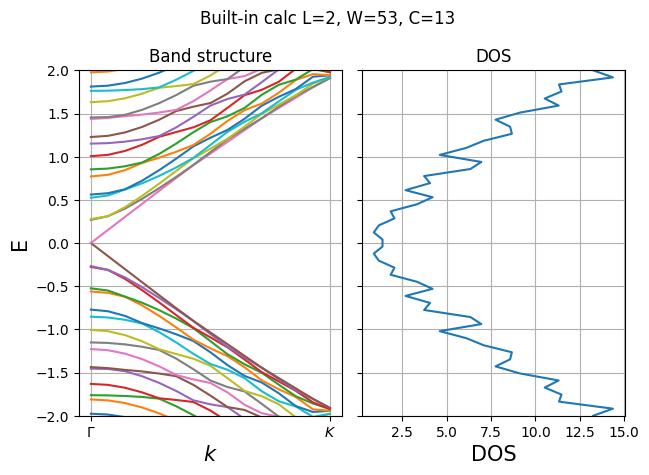

In [36]:
# multi_LDOS
fig, ax = plot_dos_band(electrode, 10, ENERGIES)
minmax=2
ax[0].set(ylim=(-minmax, minmax))


In [ ]:
from utils.energies import lr_energies, add_lr_energies, diagonal_of_inverse
from pathlib import Path

l, w, c = 1, 9, 4
E = 0

eta = 1e-5
form = "csc"

basedir = Path(Path.cwd()).resolve().parent
filedir = basedir / "results" / f"L{l}_W{w}_C{c}"
electrode = sisl.io.get_sile(filedir / "electrode.xyz").read_geometry()
ribbon = sisl.io.get_sile(filedir / "ribbon.xyz").read_geometry()
device = sisl.io.get_sile(filedir / "device.xyz").read_geometry()
DATA = np.load(filedir / "calculations.npz")
lr_idx = DATA["lr_idx"]
lr_idx = (lr_idx[0,...], lr_idx[1, ...])

H = hamiltonian(ribbon)
H.set_nsc([1,1,1])
Hk = H.Hk(format=form, dtype=complex)
Sk = H.Sk(format=form, dtype=complex)

En = E + 1j*eta
SE_pair = lr_energies(electrode, En)
lidx, ridx = lr_idx
Hk_with_lr = Hk.copy()
Hk_with_lr[np.ix_(lidx[0], lidx[0])] += SE_pair[0]
Hk_with_lr[np.ix_(ridx[0], ridx[0])] += SE_pair[1]



warn:0: SislWarning:

Geometry.close_sc has been passed an 'atoms' argument together with an R value larger than the orbital ranges. If used together with 'sparse-matrix.construct' this can result in wrong couplings.



In [123]:
pretty_print_columns(Hk_with_lr.toarray())

 0.00-62264.03j 0.00+100745.32j 0.00-100745.32j  0.00+62264.03j -2.70+0.00j -2.70+0.00j           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0           0 

In [76]:
ribbon.plot(axes="xy", atoms_style=dict(atoms=lr_idx[:, 0], color="red"))

# Note to self:
* Adjust SE-calc: $\Sigma = i\mathrm{LDOS}(E=0)c$, in Hamiltonian for the LDOS calculation find $c$
    * Try different cancstants.
    * Goal: reduced edge states when plotting PDOS (using LDOS) around E=0
* Plot LDOS (as currently) together with electrode DOS to verify behavior. Try for different widths
* Plot BG Vs. electrode width to find correlation (hopefully converging). 
    * BG is in this case equal to "flat-region" around E=0 in the LDOS plot
* Make new routine for computing LDOS for only center atoms (don't solve for all sites if used for plotting LDOS in center region).
    * Make identical routine, but only solving for atom index for the center region.


